# DPConCFil Manual 2D

### This manual mainly introduce the usage of DPConCFil for 2D data. 

#### Please see `DPConCFil_Manual.ipynb` for more details.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import astropy.io.fits as fits
from astropy import units as u
from collections import defaultdict

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append('../')
sys.path.append('../DPConCFil_2D_Code/')


In [2]:
from DPConCFil_2D_Code.Clump_Class import *
from DPConCFil_2D_Code.Filament_Class import *
import DPConCFil_2D_Code.Plot_and_Save_Funs as Plot_and_Save_Funs
import DPConCFil_2D_Code.Profile_Funs as Profile_Funs
from DPConCFil_2D_Code.Filament_Class_Funs_Analysis import *

In [3]:
file_example = 'Example_Fil_Sum'
file_name = '../Example_Files/Data/Example_Fil_13CO_Sum.fits'
# file_name = '../Example_Files/Data/Example_M16_Fil_13CO_Sum.fits'

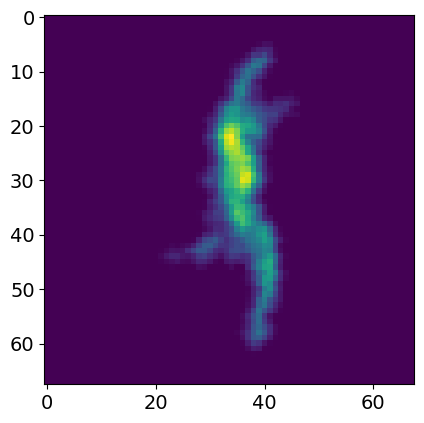

In [4]:
real_data = fits.getdata(file_name)
plt.imshow(real_data)
plt.show()

In [5]:
SWindow = 3 # [3,5,7]
KBins = 35 # [10,...,60]
FwhmBeam = 2
VeloRes = 2
SRecursionLBV = [16, 5] # [(2+FwhmBeam)**2,3+VeloRes]

header = fits.getheader(file_name)
# RMS = header['RMS']
RMS = 0.2
Threshold = 5 * RMS

parameters_FacetClumps = [RMS, Threshold, SWindow, KBins, FwhmBeam, VeloRes, SRecursionLBV]

In [6]:
mask_name = '../Example_Files/Clump/mask_{}.fits'.format(file_example)
outcat_name = '../Example_Files/Clump/outcat_{}.csv'.format(file_example)
outcat_wcs_name = '../Example_Files/Clump/outcat_wcs_{}.csv'.format(file_example)

In [7]:
clumpsObj = ClumpInfor(file_name,mask_name,outcat_name,outcat_wcs_name)

### Calculate the clump information from FacetClumps. 

In this case, the parameters of FacetClumps is essential. More clump detection algorithms can also be added to this process. 

The angle of the clumps detected by FacetClumps is obtained by diagonalizing the moment of inertia matrix, please the article of [FacetClumps](https://iopscience.iop.org/article/10.3847/1538-4365/acda89) for more details. Performing a two-dimensional single Gaussian fitting on the velocity integrated map of a clump can provide more accurate position and direction information of the clump in spatial direction. 

When 'fit_flag=True', it indicates that the fitting will be used. This will benefit the performance of DPConFil.

In [8]:
clumpsObj.Cal_Infor_From_Mask_Or_Algorithm(mask_or_algorithm='FacetClumps',parameters=parameters_FacetClumps)
clumpsObj.Get_Clumps_Infor(fit_flag = True)

100%|██████████| 1/1 [00:00<00:00, 365.64it/s]


Number: 6
Time: 0.17


100%|██████████| 6/6 [00:00<00:00, 130.70it/s]

Fitting Clumps Time: 0.05


In [9]:
clumpsObj.Cal_Infor_From_Mask_Or_Algorithm(mask_or_algorithm='mask')
clumpsObj.Get_Clumps_Infor(fit_flag = True)

Number: 6
Time: 0.02


100%|██████████| 6/6 [00:00<00:00, 129.56it/s]

Fitting Clumps Time: 0.05


Plot the original image. If save_path=None, the image will not be saved.

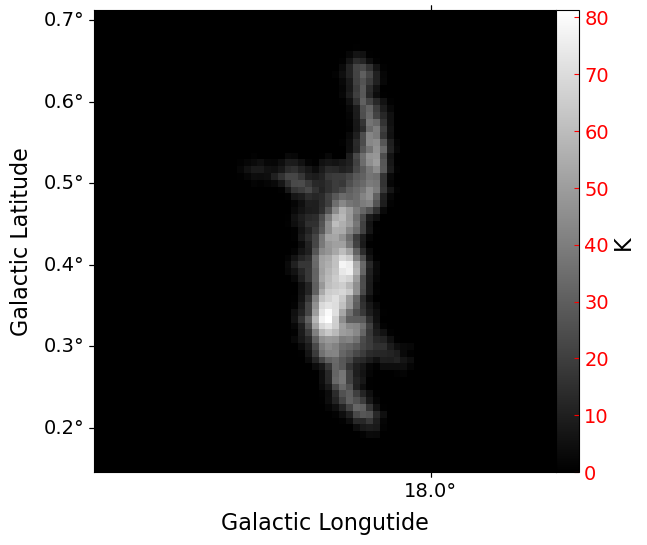

In [10]:
save_path = '../Images/Example_Data.pdf'
Plot_and_Save_Funs.Plot_Origin_Data(clumpsObj,figsize=(8,6),fontsize=16,spacing=60*u.arcmin,save_path=None)

In [11]:
edges = clumpsObj.edges
print('Total number:',len(edges))
print('NO edges number:',np.where(edges==0)[0].shape[0])

Total number: 6
NO edges number: 6


<Axes: >

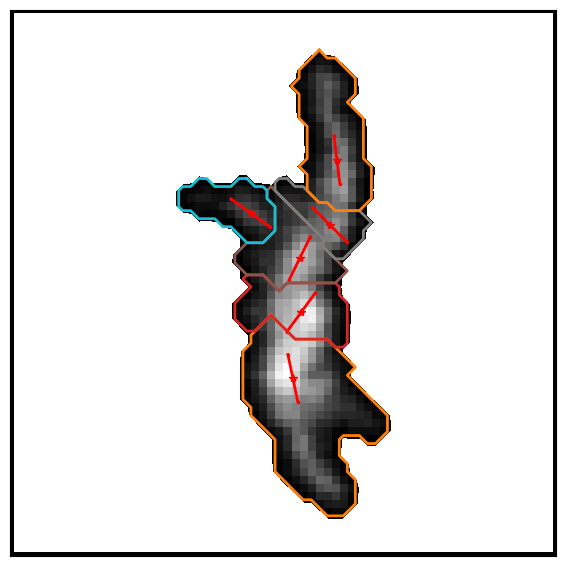

In [12]:
save_path = '../Images/Clumps_Infor.pdf'
Plot_and_Save_Funs.Plot_Clumps_Infor(clumpsObj,figsize=(8,6),line_scale=3,save_path=None)

In [13]:
filament_centers_LB = []
max_path_record = []
max_edges_record = []

data_wcs = clumpsObj.data_wcs
origin_data = clumpsObj.origin_data
regions_data = clumpsObj.regions_data
centers = clumpsObj.centers
connected_ids_dict = clumpsObj.connected_ids_dict

filament_clumps_id = np.int64(np.linspace(0,len(clumpsObj.centers)-1,len(clumpsObj.centers)))

for index in filament_clumps_id:
    filament_centers_LB.append([centers[index][1],centers[index][0]])
filament_centers_LB = np.array(filament_centers_LB)
filament_clumps_id = np.array(filament_clumps_id)

filament_mask_2D = regions_data
Graph,Tree = FCFA.Graph_Infor_SubStructure(origin_data,filament_mask_2D,filament_centers_LB,\
                                           filament_clumps_id,connected_ids_dict)

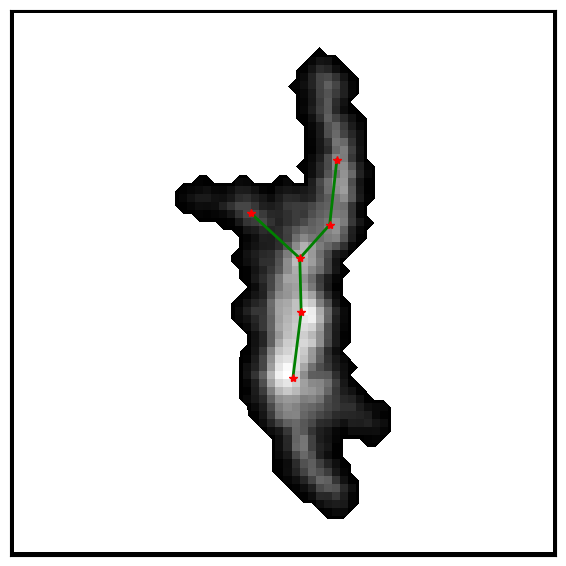

In [14]:
fig, ax0 = plt.subplots(1,1,figsize=(8, 6))
for edge in Tree.edges:
    ax0.plot([filament_centers_LB[edge[0]][0],filament_centers_LB[edge[1]][0]], \
             [filament_centers_LB[edge[0]][1],filament_centers_LB[edge[1]][1]],\
             'green', label='fit', lw=2, alpha=1.0, markersize = 8.)
for filament_center_LB in filament_centers_LB:
    ax0.plot(filament_center_LB[0],filament_center_LB[1],'r*')
    
ax0.imshow(origin_data,
               origin='lower',
               cmap='gray',
               interpolation='none')
ax0.contourf(origin_data,
             levels = [0., .01],
             colors = 'w')

fig.tight_layout()
plt.xticks([]),plt.yticks([])
plt.show()

In [15]:
TolAngle = 30
TolDistance = 4
LBRatio = 2.5
SmallSkeleton = 16
SkeletonType = 'Intensity' #Morphology, Intensity

parameters_DPConFil = [TolAngle,TolDistance,LBRatio]

In [16]:
file_index = 1
file_lines = ['12CO','13CO','C18O']
file_line = file_lines[1]

filament_mask_name = '../Example_Files/Filament/Mask_{}_{}.fits'.format(file_index,file_line)
filament_table_pix_name = '../Example_Files/Filament/Table_Pix_{}_{}.csv'.format(file_index,file_line)
filament_table_wcs_name = '../Example_Files/Filament/Table_WCS_{}_{}.csv'.format(file_index,file_line)
filament_infor_name = '../Example_Files/Filament/Infor_{}_{}'.format(file_index,file_line)

save_files = [filament_mask_name,filament_table_pix_name,filament_table_wcs_name,filament_infor_name]

## DPConFil: Simplified Process

We demonstrate the simplified process of identifying and analyzing filaments using all the sub-methods of `DPConCFil`. 

Construct filament objects. 

In [17]:
filamentObj = FilamentInfor(clumpsObj,parameters_DPConFil,save_files,SkeletonType,SmallSkeleton)

By using the function `Filament_Detect`, we can directly obtain information about the connection between filaments and clumps, as well as the regions and tables associated with the filaments, among other things.

In [18]:
filament_infor_all,Filament_Table_Pix,Filament_Table_WCS = filamentObj.Filament_Detect()

related_ids = filament_infor_all['related_ids']
print('Filament Keys:',list(related_ids.keys()))

print('Filament_Table_Pix:\n',Filament_Table_Pix)
print('Filament_Table_WCS:\n',Filament_Table_WCS)

100%|██████████| 1/1 [00:00<00:00,  2.10it/s]

Number: 1
Time: 0.49
Filament Keys: [0]
Filament_Table_Pix:
  ID  CenL   CenB  Length Area LWRatio Angle Clumps
     pix    pix    pix   pix           deg        
--- ------ ------ ------ ---- ------- ----- ------
  1 27.034 35.755     43  471    3.58 89.94      4
Filament_Table_WCS:
  ID  CenL   CenB Length   Area  LWRatio Angle Clumps
     deg    deg  arcmin arcmin2          deg        
--- ------ ----- ------ ------- ------- ----- ------
  1 18.110 0.375  21.50  117.75    3.58 89.94      4


The performance of the consistency-based identification method in two-dimensional data is suboptimal with the default parameters.

Further analysis can be conducted using the provided clump-filament relationship dictionary `related_ids`. 

If no filament, redeuce `LBRatio` .

In [19]:
filament_clumps_id = np.int64(np.linspace(0,len(clumpsObj.centers)-1,len(clumpsObj.centers)))
related_ids = {}
related_ids[0] = list(filament_clumps_id)

In [20]:
filament_infor_all,Filament_Table_Pix,Filament_Table_WCS = filamentObj.Filament_Detect(related_ids)

related_ids = filament_infor_all['related_ids']
print('Filament Keys:',list(related_ids.keys()))

print('Filament_Table_Pix:\n',Filament_Table_Pix)
print('Filament_Table_WCS:\n',Filament_Table_WCS)

100%|██████████| 1/1 [00:01<00:00,  1.68s/it]

Number: 1
Time: 1.69
Filament Keys: [0]
Filament_Table_Pix:
  ID  CenL   CenB  Length Area LWRatio Angle Clumps
     pix    pix    pix   pix           deg        
--- ------ ------ ------ ---- ------- ----- ------
  1 31.097 36.134     55  667    4.58 86.12      6
Filament_Table_WCS:
  ID  CenL   CenB Length   Area  LWRatio Angle Clumps
     deg    deg  arcmin arcmin2          deg        
--- ------ ----- ------ ------- ------- ----- ------
  1 18.107 0.409  27.50  166.75    4.58 86.12      6


In [21]:
ShowId = 0
SampInt = 2
Substructure = True

filament_clumps_id = related_ids[ShowId]
filamentObj.Filament_Infor_I(filament_clumps_id)

In [22]:
filament_coords = filamentObj.filament_coords
print('The volume of the filament:',len(filament_coords[:,0]))

The volume of the filament: 667


show_id: 0
length: 6


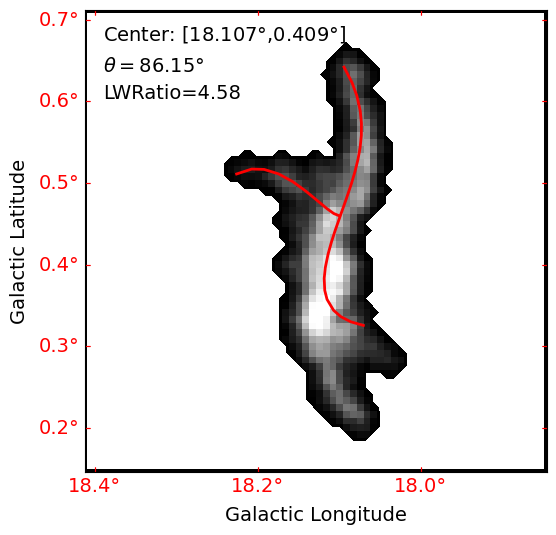

In [23]:
for show_id in related_ids.keys():
    print('show_id:',show_id)
    filament_clumps_id = related_ids[show_id]
    print('length:',len(filament_clumps_id))
    filamentObj.Filament_Infor_I(filament_clumps_id)
    fil_image = filamentObj.filament_data.sum(0)
    
    dictionary_cuts = defaultdict(list)
    dictionary_cuts = filamentObj.Get_Item_Dictionary_Cuts(filament_clumps_id,dictionary_cuts,SampInt,Substructure)
    
    save_path = '../Images/Filament_Fit_Spine_{}'.format(index)
    Plot_and_Save_Funs.Plot_Filament_Item(filamentObj,figsize=(8,6),fontsize=14,spacing=12*u.arcmin,save_path=None)

Time: 2.85


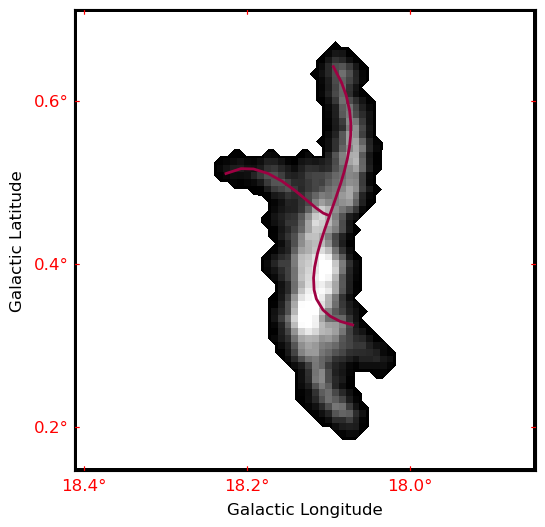

In [24]:
start_1 = time.time()

save_path = 'All'

dictionary_cuts = defaultdict(list)
for show_id in related_ids.keys():
    filament_clumps_id = related_ids[show_id]
    filamentObj.Filament_Infor_I(filament_clumps_id)
    dictionary_cuts = filamentObj.Get_Item_Dictionary_Cuts(filament_clumps_id,dictionary_cuts,SampInt,Substructure)
    
Plot_and_Save_Funs.Plot_Filament(filamentObj,figsize=(8, 6),colors=None,background='fils_data',cmap='gray',\
                                 fontsize=12,spacing=12*u.arcmin,save_path=None)

end_1 = time.time()
delta_time = np.around(end_1 - start_1, 2)
print('Time:', delta_time)

In [25]:
EProfileTime = 3
EProfileLen = 6
ExtendRange = 20
MeanProfile = True

In [26]:
Profile_Funs.Cal_Mean_Profile(filamentObj,EProfileTime,EProfileLen,ExtendRange)
Profile_Funs.Cal_Profile_IOU(filamentObj)

profile_IOU = filamentObj.profile_IOU
print('profile_IOU:',profile_IOU)

profile_IOU: 0.62


In [27]:
Profile_Funs.Construct_radObj(filamentObj)

==== Gaussian ====
amplitude: 4.309E+01
mean: 0.000
width: 2.979
The statistical uncertainty on the best-fit amplitude is 1.473
The statistical uncertainty on the best-fit mean is 0.148
==== Plummer-like ====
amplitude: 4.638E+01
p: 2.785
R_flat: -2.805
The statistical uncertainty on the best-fit amplitude is 1.995
The statistical uncertainty on the best-fit powerIndex is 0.577
The statistical uncertainty on the best-fit flatteningRadius is 0.785


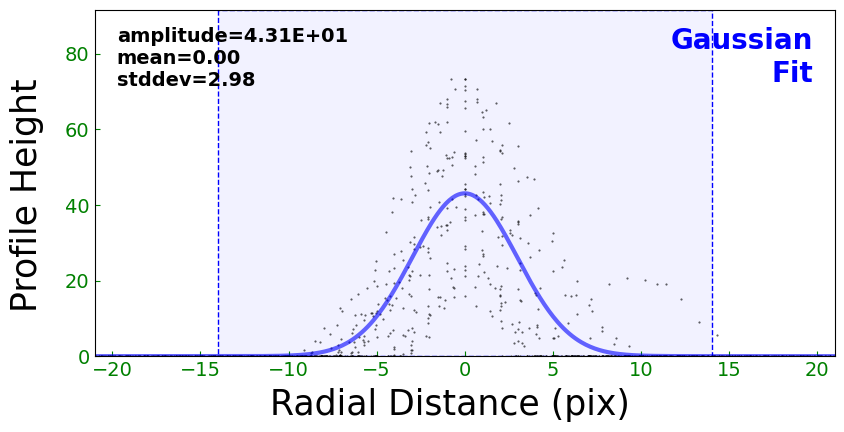

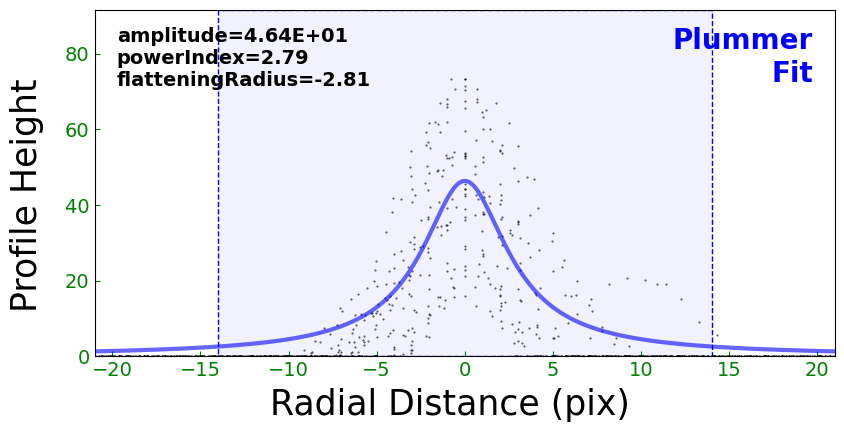

In [28]:
FitFunc = 'Plummer' #Plummer,Gaussian
FitDist = None
FitMeanProfile = False
BGDist = None
BGDegree = 0
BeamWidth = None

for FitFunc in ['Gaussian','Plummer']:
    Profile_Funs.Fit_Profile(filamentObj,FitFunc,FitDist,FitMeanProfile,BGDist,BGDegree,BeamWidth)
    
    for (name,error) in zip(filamentObj.radObj.profilefit.param_names,filamentObj.radObj.std_error): 
        print("The statistical uncertainty on the best-fit {} is {}".format(name,np.around(error,3)))

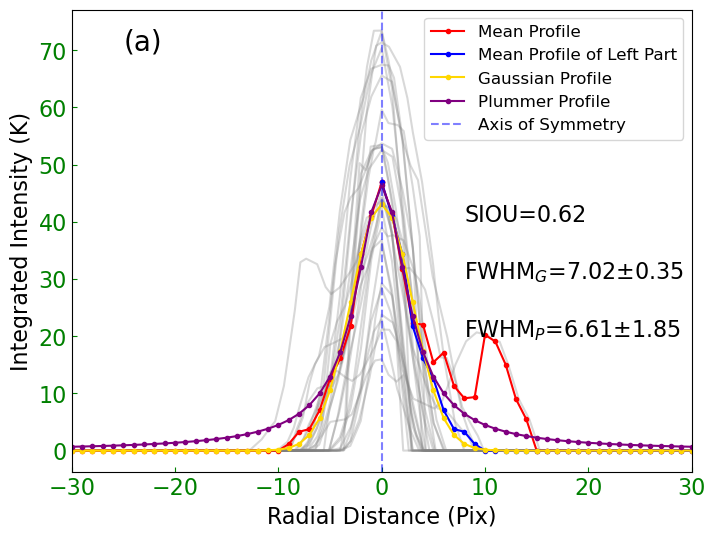

In [29]:
fontsize = 16
dictionary_cuts = filamentObj.dictionary_cuts

fig,(ax0)= plt.subplots(1,1, figsize=(8, 6))
for i in range(0,len(dictionary_cuts['distance'])):
    dists_i = dictionary_cuts['distance'][i][np.where(dictionary_cuts['profile'][i]!=0)]
    delta_dist = dists_i[-1]-dists_i[0]
    if delta_dist>filamentObj.EProfileLen:
        ax0.plot(dictionary_cuts['distance'][i], dictionary_cuts['profile'][i],c='gray',alpha=0.3)

ax0.plot(filamentObj.axis_coords_left, filamentObj.mean_profile_left,c='r',marker='.',alpha=1,label='Mean Profile')
ax0.plot(filamentObj.axis_coords_right, filamentObj.mean_profile_right,c='r',marker='.',alpha=1)
ax0.plot(filamentObj.axis_coords_right, filamentObj.mean_profile_left_r,c='b',marker='.',alpha=1,label='Mean Profile of Left Part')
ax0.plot(filamentObj.axis_coords, filamentObj.profile_fited_G,c='gold',marker='.',alpha=1,label='Gaussian Profile')
ax0.plot(filamentObj.axis_coords, filamentObj.profile_fited_P,c='purple',marker='.',alpha=1,label='Plummer Profile')

ax0.axvline(0, color='b', linestyle='dashed',alpha=0.5,label='Axis of Symmetry')
ax0.text(-25,70,'(a)',color='black',fontsize=fontsize+4)
ax0.text(8,40,'SIOU={}'.format(filamentObj.profile_IOU),color='black',fontsize=fontsize)
ax0.text(8,30,'FWHM$_G$={}$\pm${}'.format(filamentObj.FWHM_G,filamentObj.FWHM_error_G),color='black',fontsize=fontsize)
ax0.text(8,20,'FWHM$_P$={}$\pm${}'.format(filamentObj.FWHM_P,filamentObj.FWHM_error_P),color='black',fontsize=fontsize)
plt.xlim(-30,30)
plt.xlabel("Radial Distance (Pix)",fontsize=fontsize)
plt.ylabel(r"Integrated Intensity (K)",fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=fontsize)
plt.legend(fontsize=fontsize-4)
# plt.savefig('../Images/Intensity_Profile_Fited.pdf', format='pdf', dpi=1000)
plt.show()

100%|██████████| 1/1 [00:00<00:00, 21.25it/s]


Number: 94
Time: 1.44


100%|██████████| 94/94 [00:01<00:00, 93.82it/s] 


Fitting Clumps Time: 1.0


<Axes: >

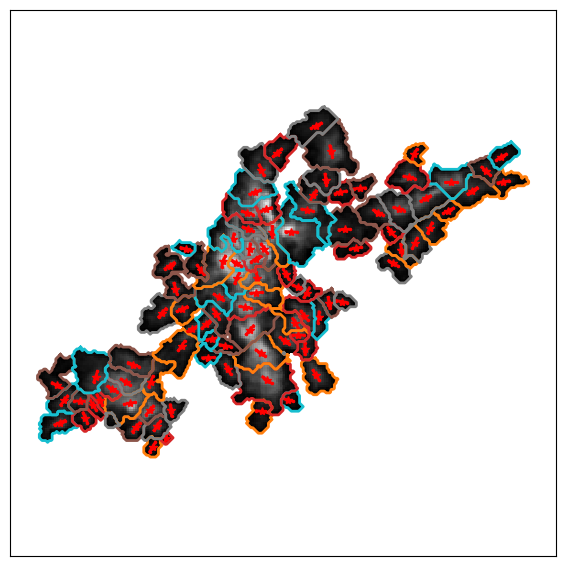

In [30]:
file_example = 'Example_Fil_Sum'
# file_name = '../Example_Files/Data/Example_Fil_13CO_Sum.fits'
file_name = '../Example_Files/Data/Example_M16_Fil_13CO_Sum.fits'

clumpsObj = ClumpInfor(file_name,mask_name,outcat_name,outcat_wcs_name)

clumpsObj.Cal_Infor_From_Mask_Or_Algorithm(mask_or_algorithm='FacetClumps',parameters=parameters_FacetClumps)
clumpsObj.Get_Clumps_Infor(fit_flag = True)

save_path = '../Images/Clumps_Infor.pdf'
Plot_and_Save_Funs.Plot_Clumps_Infor(clumpsObj,figsize=(8,6),line_scale=3,save_path=None)

In [31]:
filamentObj = FilamentInfor(clumpsObj,parameters_DPConFil,save_files,SkeletonType)

filament_clumps_id = np.int64(np.linspace(0,len(clumpsObj.centers)-1,len(clumpsObj.centers)))

related_ids = {}
related_ids[0] = list(filament_clumps_id)

filament_infor_all,Filament_Table_Pix,Filament_Table_WCS = filamentObj.Filament_Detect(related_ids)

related_ids = filament_infor_all['related_ids']
print('Filament Keys:',list(related_ids.keys()))

print('Filament_Table_Pix:\n',Filament_Table_Pix)
print('Filament_Table_WCS:\n',Filament_Table_WCS)

100%|██████████| 1/1 [59:20<00:00, 3560.17s/it]

Number: 1
Time: 3560.18
Filament Keys: [0]
Filament_Table_Pix:
  ID   CenL    CenB  Length  Area LWRatio Angle Clumps
      pix     pix    pix    pix           deg        
--- ------- ------- ------ ----- ------- ----- ------
  1 147.733 134.503    376 17151    8.68 39.41     94
Filament_Table_WCS:
  ID  CenL   CenB Length   Area  LWRatio Angle Clumps
     deg    deg  arcmin arcmin2          deg        
--- ------ ----- ------ ------- ------- ----- ------
  1 17.062 0.714 188.00 4288.00    8.68 39.41     94


ID: 0


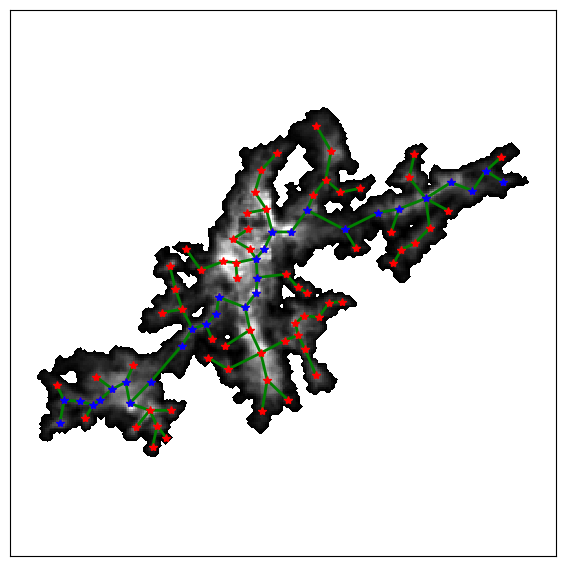

In [32]:
filament_item, Tree, centers_item_LB, max_path_record = FCFA.Cal_Tree_By_Clump_IDs(filamentObj, filament_clumps_id)

for i in range(1):#len(max_path_record)
    print('ID:',i)
    fig, ax0 = plt.subplots(1,1,figsize=(8, 6))
    for edge in Tree.edges:
        ax0.plot([centers_item_LB[edge[0]][0],centers_item_LB[edge[1]][0]], \
                [centers_item_LB[edge[0]][1],centers_item_LB[edge[1]][1]],\
                'green', label='fit', lw=2, alpha=1.0, markersize = 8.)
    for center_item_LBV in centers_item_LB:
        ax0.plot(center_item_LBV[0],center_item_LBV[1],'r*')

    for center_item_LBV in centers_item_LB[max_path_record[i]]:
        ax0.plot(center_item_LBV[0],center_item_LBV[1],color='blue',marker='*')

    show_data = filament_item
    vmin = np.min(show_data[show_data != 0])
    vmax = np.nanpercentile(show_data[np.where(show_data != 0)], 99.5)
    gci = ax0.imshow(show_data,
            origin='lower',
            interpolation='none',
            cmap='gray',
            norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    ax0.contourf(show_data,
                levels=[0., .0001],
                colors='w')

    fig.tight_layout()
    plt.xticks([]),plt.yticks([])
    plt.show()

In [33]:
# def Get_Max_Path_Intensity_Weighted(fil_mask, mask_coords, Tree, common_mask_coords_id=None, common_mask_coords_centers_id=None):
#     """
#     Determine the maximum intensity-weighted path within a filament mask.

#     The function searches for the most significant path in a graph (Tree) derived
#     from a filament mask. The path is evaluated using inverse edge weights,
#     which typically correspond to intensity (i.e., higher intensity → larger contribution).

#     Two modes are supported:
#     1. If `common_mask_coords_id` is provided, paths are constrained to pass through
#        specified nodes.
#     2. Otherwise, paths are searched between all endpoint pairs of the tree.

#     Parameters
#     ----------
#     fil_mask : ndarray
#         2D binary mask of the filament.
#     mask_coords : ndarray
#         Array of coordinates corresponding to mask nodes (index-aligned with Tree nodes).
#     Tree : networkx.Graph
#         Minimum spanning tree (or skeleton graph) of the filament.
#     common_mask_coords_id : list, optional
#         Node indices that must be included as starting points of candidate paths.
#     common_mask_coords_centers_id : list, optional
#         Subset of important nodes (e.g., centers) that the path is preferred to pass through.

#     Returns
#     -------
#     max_path : list
#         Node index sequence representing the optimal path.
#     max_edges : list
#         List of edge tuples (node_i, node_j) corresponding to the optimal path.
#     """

#     # Fill internal holes in the mask and extract contour information
#     fil_mask, contour_data = Fill_Mask_Holes(fil_mask)
    
#     # Identify endpoint nodes: degree == 1 AND located on the mask boundary
#     degree1_nodes = [node for node in Tree.nodes if Tree.degree(node) == 1 and 
#                                         contour_data[mask_coords[node][0], mask_coords[node][1]]]
    
#     paths_and_weights = []

#     # Case 1: Constrained paths through specified common nodes
#     if common_mask_coords_id is not None and len(common_mask_coords_id) > 0:
#         for i in common_mask_coords_id:
#             for j in range(len(degree1_nodes)):
#                 # Shortest path from constrained node to endpoint
#                 path = nx.shortest_path(Tree, i, degree1_nodes[j])

#                 # Prefer paths passing through specified center nodes
#                 if common_mask_coords_centers_id[0] in path: 
#                     path_weight = 0

#                     # Compute path weight: sum of inverse edge weights
#                     for k in range(len(path) - 1):
#                         weight = Tree[path[k]][path[k + 1]]['weight']
#                         if weight != 0:
#                             path_weight += 1 / weight

#                     paths_and_weights.append((path, path_weight))

#     # Case 2: Unconstrained — search all endpoint-to-endpoint paths
#     else:
#         for i in range(len(degree1_nodes) - 1):
#             for j in range(i + 1, len(degree1_nodes)):
#                 # Shortest path between two endpoints
#                 path = nx.shortest_path(Tree, degree1_nodes[i], degree1_nodes[j])
#                 if type(common_mask_coords_centers_id) is not type(None):
#                     if common_mask_coords_centers_id[0] in path and common_mask_coords_centers_id[-1] in path:
#                         path_weight = 0
#                         # Compute path weight: sum of inverse edge weights
#                         for k in range(len(path) - 1):
#                             weight = Tree[path[k]][path[k + 1]]['weight']
#                             if weight != 0:
#                                 path_weight += 1 / weight
#                         paths_and_weights.append((path, path_weight))
#                 else:
#                     path_weight = 0
#                     # Compute path weight: sum of inverse edge weights
#                     for k in range(len(path) - 1):
#                         weight = Tree[path[k]][path[k + 1]]['weight']
#                         if weight != 0:
#                             path_weight += 1 / weight
#                     paths_and_weights.append((path, path_weight))

#     # Fallback: if no path satisfies center constraint, relax condition
#     if len(paths_and_weights) == 0:
#         for i in common_mask_coords_id:
#             for j in range(len(degree1_nodes)):
#                 path = nx.shortest_path(Tree, i, degree1_nodes[j])
#                 path_weight = 0

#                 for k in range(len(path) - 1):
#                     weight = Tree[path[k]][path[k + 1]]['weight']
#                     if weight != 0:
#                         path_weight += 1 / weight

#                 paths_and_weights.append((path, path_weight))

#     # Select the path with the maximum accumulated weight
#     # print('paths_and_weights:',paths_and_weights)
#     max_weight, max_path, max_edges = Search_Max_Path_And_Edges(paths_and_weights)
    
#     return max_path, max_edges


# def Get_Single_Filament_Skeleton_Weighted(fil_image, fil_mask, clump_numbers, common_sc_item=None, sub_centers_item=None, SmallSkeleton=6):
#     """
#     Extract an intensity-weighted skeleton from a filament mask.
    
#     This function creates a graph from mask coordinates with weights based on
#     intensity, then finds the longest path through this graph to represent
#     the filament's spine.
    
#     Parameters:
#     -----------
#     fil_image : ndarray
#         2D intensity image of the filament
#     fil_mask : ndarray
#         Binary mask of the filament
#     clump_numbers : int
#         Number of clumps in the filament
#     common_sc_item : ndarray, optional
#         Common skeleton coordinates to include in the path
#     SmallSkeleton : int, optional
#         Threshold to define a "small" skeleton
        
#     Returns:
#     --------
#     skeleton_coords_2D : ndarray
#         Coordinates of the intensity-weighted skeleton
#     small_sc : bool
#         Flag indicating if the skeleton is considered "small"
#     """
#     # Flag to indicate if we're using common skeleton coordinates
#     CalSubSK = type(common_sc_item) != type(None)
    
#     # Apply a smoothing filter to reduce noise
#     fil_image_filtered = ndimage.uniform_filter(fil_image, size=3)
    
#     # Get coordinates of all pixels in the mask
#     regions_list = measure.regionprops(np.array(fil_mask, dtype='int'))
#     mask_coords = regions_list[0].coords
    
#     # Calculate distances between neighboring coordinates
#     dist_matrix = Dists_Array(mask_coords, mask_coords)
#     mask_coords_in_dm = np.where(np.logical_and(dist_matrix > 0.5, dist_matrix < 2))
    
#     # Create a graph with edges between neighboring pixels
#     Graph_find_skeleton = nx.Graph()
#     common_mask_coords_id = []
#     common_mask_coords_centers_id = []
    
#     # Add edges with weights inversely proportional to intensity
#     for i, j in zip(mask_coords_in_dm[0], mask_coords_in_dm[1]):
#         weight_ij = fil_image_filtered[mask_coords[i][0], mask_coords[i][1]] + \
#                     fil_image_filtered[mask_coords[j][0], mask_coords[j][1]]
        
#         # Set weight to 0 if intensity is 0, otherwise make it inversely proportional
#         if weight_ij != 0:
#             weight_ij = dist_matrix[i, j] / weight_ij
        
#         # Add edge to graph
#         Graph_find_skeleton.add_edge(i, j, weight=weight_ij)
        
#         # If using common skeleton coordinates, record their IDs
#         if type(common_sc_item) != type(None):
#             if tuple(mask_coords[i]) in map(tuple, common_sc_item) and i not in common_mask_coords_id:
#                 common_mask_coords_id.append(i)
#         if type(sub_centers_item) != type(None):
#             if tuple(mask_coords[i]) in map(tuple, sub_centers_item) and i not in common_mask_coords_centers_id:
#                 common_mask_coords_centers_id.append(i)
            
#     # Create unique list of common coordinate IDs
#     if type(common_sc_item) == type(None):
#         common_mask_coords_id = None
    
#     if type(sub_centers_item) == type(None) or len(common_mask_coords_centers_id)==0:
#         common_mask_coords_centers_id = None
#     else:
#         sort_ids = np.array([{tuple(r): i for i, r in enumerate(mask_coords[common_mask_coords_centers_id])}[tuple(row)] for row in sub_centers_item])
#         common_mask_coords_centers_id = np.array(common_mask_coords_centers_id)[sort_ids]

#     # print('common_mask_coords_id:',common_mask_coords_id)
#     # print('common_mask_coords_centers_id:',common_mask_coords_centers_id)
#     # Find minimum spanning tree
#     Tree = nx.minimum_spanning_tree(Graph_find_skeleton)
    
#     # Find the longest path through the tree
#     # print('CalSubSK:',CalSubSK)
#     if clump_numbers < 100 or CalSubSK:
#         max_path, max_edges = Get_Max_Path_Intensity_Weighted(fil_mask, mask_coords, Tree, \
#                                                               common_mask_coords_id,common_mask_coords_centers_id)
#     else:
#         max_path, max_edges = Get_Max_Path_Intensity_Weighted_Fast(fil_mask, mask_coords, Tree, clump_numbers)

#     # Extract coordinates for the maximum path
#     skeleton_coords_2D = mask_coords[max_path]
        
#     # Trim and refine the skeleton
#     skeleton_coords_2D, small_sc = Trim_Skeleton_Coords_2D(skeleton_coords_2D, SmallSkeleton)
#     # print('skeleton_coords_2D:',small_sc, skeleton_coords_2D)
#     return skeleton_coords_2D, small_sc


# FCFA.Get_Single_Filament_Skeleton_Weighted = Get_Single_Filament_Skeleton_Weighted

# FCFA.Get_Max_Path_Intensity_Weighted = Get_Max_Path_Intensity_Weighted

In [34]:
# def Get_Item_Dictionary_Cuts(self, filament_clumps_id, dictionary_cuts=None, SampInt=1, Substructure=False):
#         self.SampInt = SampInt
#         self.Substructure = Substructure
#         SkeletonType = self.SkeletonType
#         SmallSkeleton = self.SmallSkeleton
#         centers = self.clumpsObj.centers
#         origin_data = self.clumpsObj.origin_data
#         regions_data = self.clumpsObj.regions_data
#         data_wcs = self.clumpsObj.data_wcs
#         connected_ids_dict = self.clumpsObj.connected_ids_dict
#         clump_coords_dict = self.clumpsObj.clump_coords_dict
#         filament_coords = self.filament_coords

#         filament_centers_LB = []
#         max_path_record = []
#         max_edges_record = []

#         for index in filament_clumps_id:
#             filament_centers_LB.append([centers[index][1], centers[index][0]])
#         filament_centers_LB = np.array(filament_centers_LB)
#         filament_clumps_id = np.array(filament_clumps_id)
#         self.filament_centers_LB = filament_centers_LB

#         filament_mask_2D = np.zeros((regions_data.shape[0], regions_data.shape[1]), dtype=np.int16)
#         filament_mask_2D[filament_coords[:, 0], filament_coords[:, 1]] = 1
#         fil_mask = filament_mask_2D.astype(bool)
#         Graph, Tree = FCFA.Graph_Infor_SubStructure(origin_data, fil_mask, filament_centers_LB, filament_clumps_id, \
#                                                     self.clumpsObj.connected_ids_dict)
#         max_path_record, max_edges_record = FCFA.Get_Max_Path_Recursion(origin_data, filament_centers_LB, \
#                                                                         max_path_record, max_edges_record, Graph, Tree, Tree)
#         max_path_record = FCFA.Update_Max_Path_Record(max_path_record)

#         self.CalSub = False
#         max_path_used = []
#         skeleton_coords_record = []
#         substructure_num_i = 0
#         if Substructure:
#             CalSub = True
#             substructure_ids_T = []
#             for subpart_id in range(0, len(max_path_record)):
#                 max_path_i = max_path_record[subpart_id]
#                 max_path_used.append(max_path_i)
#                 related_ids_T = np.array(filament_clumps_id)[max_path_i]

#                 if type(dictionary_cuts) != type(None) and len(related_ids_T)>0:
#                     filament_coords, filament_item, data_wcs_item, regions_data_T, start_coords, filament_item_mask_2D, lb_area = \
#                         FCFA.Filament_Coords(origin_data, regions_data, data_wcs, clump_coords_dict, related_ids_T,CalSub)

#                     fil_image = filament_item
#                     fil_mask = filament_item_mask_2D.astype(bool)

#                     common_clump_id, common_sc_item, sub_centers_item = FCFA.Get_Common_Skeleton(filament_clumps_id,related_ids_T, \
#                                                                                max_path_i, max_path_used,
#                                                                                skeleton_coords_record, start_coords,
#                                                                                clump_coords_dict,centers)
#                     if SkeletonType == 'Morphology':
#                         skeleton_coords_2D, filament_skeleton, all_skeleton_coords = FCFA.Get_Single_Filament_Skeleton(
#                             fil_mask)
#                     elif SkeletonType == 'Intensity':
#                         all_skeleton_coords = None
#                         clumps_number = len(related_ids_T)
#                         skeleton_coords_2D, small_sc = FCFA.Get_Single_Filament_Skeleton_Weighted(fil_image, fil_mask, \
#                                                                         clumps_number,common_sc_item,sub_centers_item,SmallSkeleton)
#                     else:
#                         print('Please choose the skeleton_type between Morphology and Intensity')

#                     skeleton_coords_record.append(skeleton_coords_2D + start_coords)
#                     if not small_sc:
#                         #                         skeleton_coords_record.append(skeleton_coords_2D+start_coords[1:])
#                         skeleton_coords_2D = skeleton_coords_2D + np.random.random(skeleton_coords_2D.shape) / 10000
#                         dictionary_cuts = FCFA.Cal_Dictionary_Cuts(SampInt, CalSub, regions_data_T, related_ids_T, \
#                                                                    connected_ids_dict, clump_coords_dict,
#                                                                    skeleton_coords_2D, fil_image, fil_mask, dictionary_cuts, start_coords)
#                         dictionary_cuts = FCFA.Update_Dictionary_Cuts(dictionary_cuts, start_coords)

#                         substructure_ids_T += [list(related_ids_T)]
#                         substructure_num_i += 1
#             if substructure_num_i == 0:
#                 substructure_num_i = 1
#                 substructure_ids_T = [list(filament_clumps_id)]
#             self.substructure_num += [substructure_num_i]
#             self.substructure_ids += [substructure_ids_T]
#             self.skeleton_coords_record = skeleton_coords_record
#             if len(dictionary_cuts['points']) == 0:
#                 dictionary_cuts = self.dc_no_sub
#         else:
#             if SampInt == 1:
#                 dictionary_cuts = self.dc_no_sub
#             else:
#                 start_coords = self.start_coords
#                 regions_data_T = self.regions_data_T
#                 skeleton_coords_2D = self.skeleton_coords_2D
#                 fil_image = self.filament_item
#                 fil_mask = self.filament_item_mask_2D.astype(bool)
#                 skeleton_coords_2D = skeleton_coords_2D - start_coords + np.random.random(
#                     skeleton_coords_2D.shape) / 10000
#                 dictionary_cuts = FCFA.Cal_Dictionary_Cuts(SampInt, self.CalSub, regions_data_T, filament_clumps_id, \
#                                                            connected_ids_dict, clump_coords_dict, skeleton_coords_2D,
#                                                            fil_image, fil_mask, dictionary_cuts)
#                 dictionary_cuts = FCFA.Update_Dictionary_Cuts(dictionary_cuts, start_coords)
#         self.dictionary_cuts = dictionary_cuts
#         return dictionary_cuts

In [35]:
start_1 = time.time()

save_path = 'All'

dictionary_cuts = defaultdict(list)
for show_id in related_ids.keys():
    filament_clumps_id = related_ids[show_id]
    # filamentObj.Filament_Infor_I(filament_clumps_id)
    dictionary_cuts = filamentObj.Get_Item_Dictionary_Cuts(filament_clumps_id,dictionary_cuts,SampInt,Substructure)
    
Plot_and_Save_Funs.Plot_Filament(filamentObj,figsize=(8,6),fontsize=16,spacing=None,save_path=None)

end_1 = time.time()
delta_time = np.around(end_1 - start_1, 2)
print('Time:', delta_time)

TypeError: 'NoneType' object is not iterable

### If you have any questions about this tutorial, please open an issue on github, or email the author. (yujiang@pmo.ac.cn)